##Librairies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import hashlib
from tqdm.notebook import tqdm
import os
warnings.filterwarnings('ignore')
import psutil
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from transformers import RobertaTokenizer,AutoTokenizer,AutoConfig,AutoModel
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from collections import defaultdict
from sklearn.model_selection import train_test_split
import time

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
def memory_check():
  return round(psutil.virtual_memory().used/1024**3,3)

##PPFLE Algorithm

In [4]:
def PPFLE(M):
  columns = list(data.columns[:-2])
  # print(columns)
  # return 0
  DL = []
  for i,v in tqdm(M.iterrows(),desc="Processing...",total=len(M)):
    L = []
    for j in columns:
      L.append(str(v.get(j)))
    DL.append(" ".join(L))
  return DL


In [5]:
data = pd.read_csv(".\data\Edge-IIoTset dataset\Selected dataset for ML and DL\ML-EdgeIIoT-dataset.csv")
data.head(5)

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [6]:
data['Attack_type'].value_counts()

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64

In [7]:
columns_object = data.select_dtypes(include=['object']).columns
columns_object = list(columns_object[:-2])

In [8]:
for column in tqdm(columns_object):
  data[column] = data[column].astype(str)


  0%|          | 0/18 [00:00<?, ?it/s]

In [9]:
data.sample(5)

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
122068,2021 20:38:28.360720000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
14767,2021 23:10:32.612651000,192.168.0.170,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Uploading
18178,2021 23:11:58.989482000,192.168.0.128,192.168.0.170,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Uploading
118513,2021 16:05:34.637998000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
100284,2021 18:55:20.732331000,192.168.0.128,192.168.0.170,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,XSS


In [10]:
temp = PPFLE(data)

Processing...:   0%|          | 0/157800 [00:00<?, ?it/s]

In [11]:
data['raw_input'] = temp
del temp

In [12]:
data = data[['raw_input','Attack_type','Attack_label']]

In [13]:
data.to_pickle('./saved_data/raw_data.pck')

##Load saved data

In [14]:
data = pd.read_pickle('./saved_data/raw_data.pck')

In [15]:
le = LabelEncoder()
data['target'] = le.fit_transform(data['Attack_type'])

In [16]:
data.sample(3)

,raw_input,Attack_type,Attack_label,target
86925,2021 18:19:31.181502000 192.168.0.170 192.16...,Backdoor,1,0
38278,2021 11:37:14.002334000 192.168.0.170 192.16...,DDoS_HTTP,1,1
101264,2021 19:07:57.792926000 192.168.0.128 192.16...,XSS,1,14


In [17]:
data['raw_input'][0]

'6.0 192.168.0.152 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0'

In [18]:
sorted(data['target'].unique())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [19]:
memory_check()

25.751

In [20]:
with open("raw_data_nc.txt","w") as f:
  for value in tqdm(data['raw_input']):
    f.write(str(value)+'\n')


  0%|          | 0/157800 [00:00<?, ?it/s]

##Data splitting

In [21]:
train_set = data.sample(frac=0.7,random_state=42).reset_index(drop=True)

remaining = data.drop(train_set.index).reset_index(drop=True)

test_set = remaining.sample(frac=0.5,random_state=42).reset_index(drop=True)

val_set = remaining.drop(test_set.index).reset_index(drop=True)

print(train_set.shape,val_set.shape,test_set.shape)

(110460, 4) (23670, 4) (23670, 4)


In [22]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [23]:
train_set, test_set = train_test_split(data, test_size=test_ratio,stratify=data.iloc[:,-1], random_state=42)
train_set, val_set = train_test_split(train_set, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set.iloc[:,-1], random_state=42)


In [24]:
train_set.shape,val_set.shape,test_set.shape

((110460, 4), (23670, 4), (23670, 4))

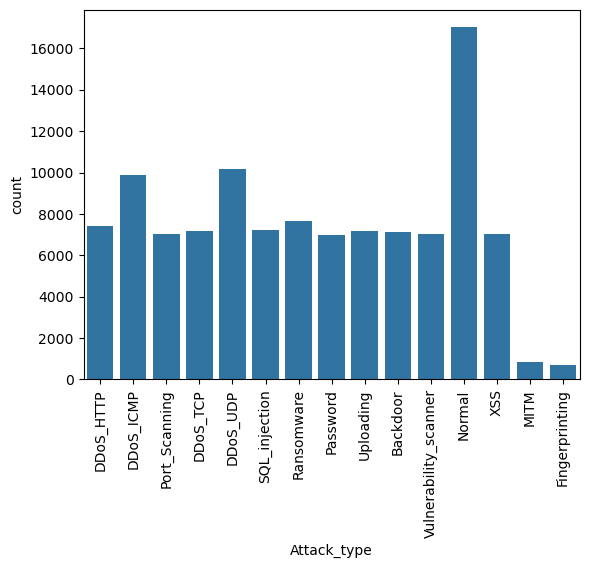

In [25]:
sns.countplot(train_set,x='Attack_type');
plt.xticks(rotation=90)
plt.show();

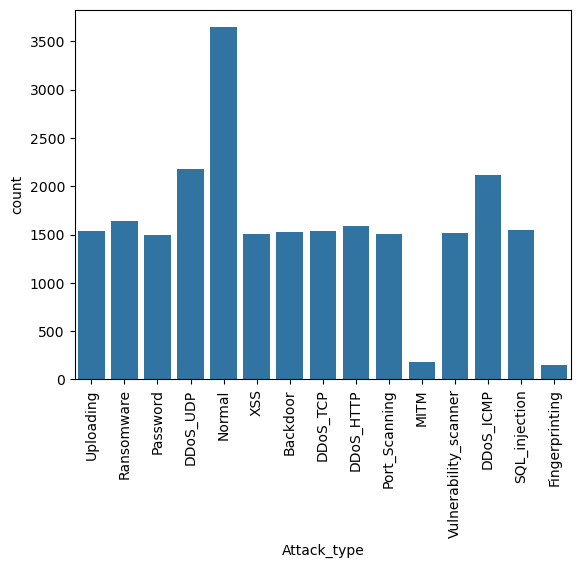

In [26]:
sns.countplot(val_set,x='Attack_type');
plt.xticks(rotation=90)
plt.show();

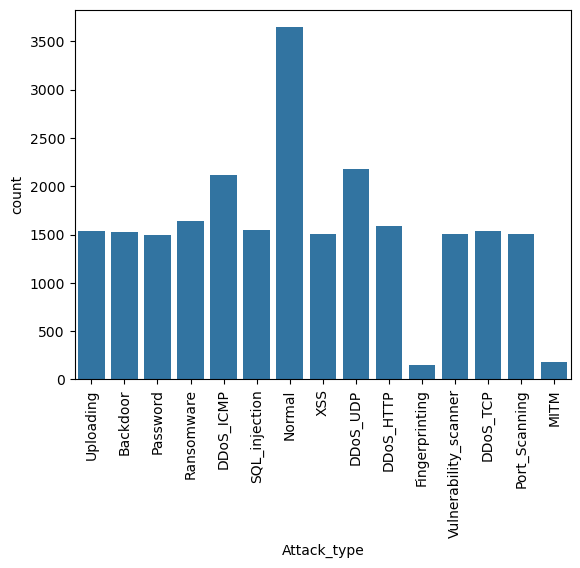

In [27]:
sns.countplot(test_set,x='Attack_type');
plt.xticks(rotation=90)
plt.show();

In [28]:
TARGET_LIST = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
                'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
                'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
                'XSS']

In [29]:
data[data['Attack_type']=='Uploading'].head(5)

,raw_input,Attack_type,Attack_label,target
13140,2021 23:08:50.405398000 192.168.0.128 192.16...,Uploading,1,12
13141,2021 23:08:50.410132000 192.168.0.128 192.16...,Uploading,1,12
13142,2021 23:08:50.418633000 192.168.0.128 192.16...,Uploading,1,12
13143,2021 23:08:50.422226000 192.168.0.170 192.16...,Uploading,1,12
13144,2021 23:08:50.429837000 192.168.0.128 192.16...,Uploading,1,12


##BBPE algorithm

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [31]:
from tokenizers import ByteLevelBPETokenizer

In [32]:
tokenizer = ByteLevelBPETokenizer()

In [ ]:
%%time
tokenizer.train('./raw_data.txt',vocab_size=5000,min_frequency=2,
                special_tokens=[
                    '<s>','<pad>','</s>','<unk>','<mask>'

                ])

CPU times: total: 0 ns
Wall time: 7.95 ms


os.mkdir('tokenizer')

In [ ]:
tokenizer.save_model("./tokenizer_raw/")

['./tokenizer/vocab.json', './tokenizer/merges.txt']

##Model section

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('./tokenizer_raw')

In [36]:
len(tokenizer.get_vocab())

261

##Dataset and DataLoader

In [37]:
class CustomDataset(Dataset):
  def __init__(self,df,tokenizer,max_len):
    self.df = df
    self.tokenizer = tokenizer
    self.max_len=max_len
    self.sequence = self.df['raw_input'].tolist()
    self.targets = self.df['target'].tolist()

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    sequence = str(self.sequence[idx])
    target = self.targets[idx]
    encoding = self.tokenizer.encode_plus(
        sequence,
        add_special_tokens=True,
        max_length=self.max_len,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    return {
        'input_ids':encoding['input_ids'].flatten(),
        'attention_mask':encoding['attention_mask'].flatten(),
        'targets':torch.tensor(target,dtype=torch.long)
    }


In [38]:
MAX_LEN=512
BATCH_SIZE=32

In [39]:
train_dataset = CustomDataset(train_set,tokenizer=tokenizer,max_len=MAX_LEN)
val_dataset = CustomDataset(val_set,tokenizer=tokenizer,max_len=MAX_LEN)
test_dataset = CustomDataset(test_set,tokenizer=tokenizer,max_len=MAX_LEN)

In [40]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0

)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

#Fine tuning BERT

In [41]:
config = AutoConfig.from_pretrained("bert-base-uncased")
config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.0.dev0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [42]:
config.hidden_size = 256
config.num_hidden_layers = 4
config.num_attention_heads = 16
config.intermediate_size = 512
config.vocab_size=5000

config.cls_token_id=tokenizer.convert_tokens_to_ids("<s>")
config.sep_token_id=tokenizer.convert_tokens_to_ids("</s>")
config.pad_token_id=tokenizer.convert_tokens_to_ids("<pad>")
config.mask_token_id=tokenizer.convert_tokens_to_ids("<mask>")
config.unk_token_id=tokenizer.convert_tokens_to_ids("<unk>") # This line was not run to build the model

In [43]:
finetunedBERT = AutoModel.from_config(config)

In [44]:
finetunedBERT

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(5000, 256, padding_idx=1)
    (position_embeddings): Embedding(512, 256)
    (token_type_embeddings): Embedding(2, 256)
    (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-3): 4 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=256, out_features=256, bias=True)
            (key): Linear(in_features=256, out_features=256, bias=True)
            (value): Linear(in_features=256, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=256, out_features=256, bias=True)
            (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

###Model paramerters

In [45]:
sum(p.numel() for p in finetunedBERT.parameters())

3586304

##Model definition

In [46]:
class SecurityBERT(nn.Module):
  def __init__(self,finetunedBERT,n_classes):
    super(SecurityBERT,self).__init__()
    self.bert = finetunedBERT
    self.dropout = nn.Dropout(p=0.1)
    self.out = nn.Linear(self.bert.config.hidden_size,n_classes)

  def forward(self,input_ids,attention_mask):
    pooled_output = self.bert(
        input_ids=input_ids,
        attention_mask=attention_mask
    ).pooler_output

    output = self.dropout(pooled_output)

    return self.out(output)


In [47]:
test_data = next(iter(train_loader))

print(test_data['input_ids'].shape)

torch.Size([32, 512])


In [48]:
# input_ids = test_data['input_ids'].to(device)
# attention_mask = test_data['attention_mask'].to(device)

# res = nn.functional.softmax(securityBert(input_ids,attention_mask),dim=1)


###Subsection of training


In [49]:
def load_chkpt(model,version):
  return model.load_state_dict(torch.load(f"./saved_model/securityBert3_mod_raw_{version}.0.pt",map_location=torch.device('cpu')))

##Training and Evaluation

In [54]:
def train_model(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    #print("input_ids shape:", input_ids.shape)
    #print("input_ids max:", input_ids.max().item())
    #print("input_ids min:", input_ids.min().item())
    #print("BERT vocab size:", model.bert.config.vocab_size)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)
    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm(model.parameters(),max_norm=1.0)

    optimizer.step()
    scheduler.step()

    optimizer.zero_grad()

  return correct_predictions/n_examples,np.mean(losses)




In [51]:
def evaluation_model(model,data_loader,loss_fn,device,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)

    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

  return correct_predictions/n_examples,np.mean(losses)

In [52]:
securityBert = SecurityBERT(finetunedBERT=finetunedBERT,n_classes=len(TARGET_LIST)).to(device)
EPOCHS=3
optimizer = torch.optim.AdamW(securityBert.parameters(),lr=1e-5)
total_steps = len(train_loader)*EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps= 0,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
%%time
history = defaultdict(list)
start_time = time.time()
best_accuracy=0
for epoch in tqdm(range(EPOCHS)):
  print(f"Epoch {epoch+1}/{EPOCHS}")
  train_acc,train_loss = train_model(securityBert,train_loader,loss_fn,optimizer,device,scheduler,len(train_set))
  val_acc,val_loss = evaluation_model(securityBert,val_loader,loss_fn,device,len(val_set))
  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)
  print(f"Train Loss {train_loss} | Validation Loss {val_loss} |Training Accuracy {train_acc} |Validation Accuracy {val_acc}")

  if val_acc>best_accuracy:
    torch.save(securityBert.state_dict(),f"./saved_model/securityBert3_mod_raw_{epoch+1}.0.pt")
    best_accuracy = val_acc

history['total_time'].append(time.time() - start_time)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3
Train Loss 1.607434014456297 | Validation Loss 0.973242052181347 |Training Accuracy 0.4788701832294464 |Validation Accuracy 0.7075623273849487
Epoch 2/3
Train Loss 0.7115942933321483 | Validation Loss 0.5054141393183051 |Training Accuracy 0.8108455538749695 |Validation Accuracy 0.878284752368927
Epoch 3/3
Train Loss 0.4335300763108501 | Validation Loss 0.3956041722080192 |Training Accuracy 0.8934546709060669 |Validation Accuracy 0.9016054272651672
CPU times: total: 27min 52s
Wall time: 28min 28s


28min 28.3s

In [56]:
torch.save(history,f"./saved_model/history_securityBert3_mod_raw_3eps.pt")
test_indices = test_set.index.to_numpy()
np.save(f"./saved_model/test_indices_securityBert3_mod_raw_3eps.npy", test_indices)

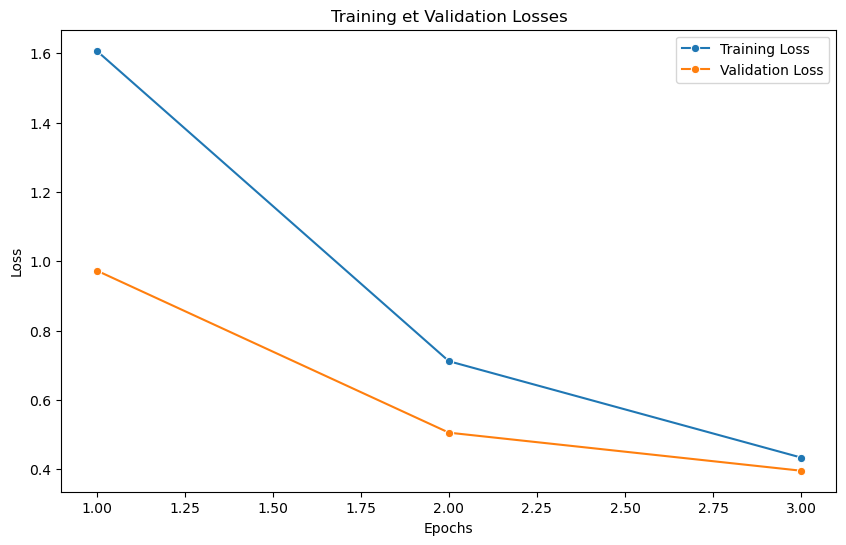

In [ ]:

epochs = range(1, EPOCHS+1)
train_losses = history['train_loss']
val_losses = history['val_loss']

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_losses, label='Training Loss',marker="o")
sns.lineplot(x=epochs, y=val_losses, label='Validation Loss',marker="o")

# Ajout de titres et de légendes
plt.title('Training et Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('./securityBert3-mod-raw-training-validation-losses.png',dpi=780)
# Affichage du graphique
plt.show()


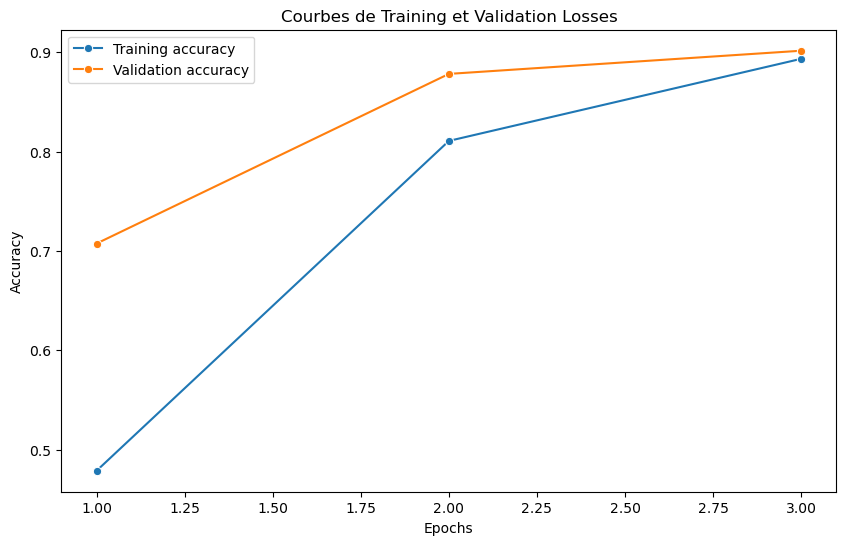

In [ ]:
epochs = range(1, EPOCHS+1)
train_accuracies = [tens.item() for tens in history['train_acc']]
val_accuracies = [tens.item() for tens in history['val_acc']]

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o')
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o')

# Ajout de titres et de légendes
plt.title('Courbes de Training et Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('./securityBert3-mod-raw-training-validation-accuracies.png',dpi=780)
# Affichage du graphique
plt.show()


In [59]:
def get_predictions(model,test_loader):
    model = model.eval()

    predictions,predictions_probs,real_values = [],[],[]

    with torch.no_grad():
        for data in tqdm(test_loader,desc="Predictions"):
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            targets = data['targets'].to(device)

            outputs = model(input_ids,attention_mask)
            _,preds = torch.max(outputs,dim=1)

            probs = F.softmax(outputs,dim=1)

            predictions.extend(preds)
            predictions_probs.extend(probs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    predictions_probs = torch.stack(predictions_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return predictions,predictions_probs,real_values



In [60]:
predictions,predictions_probs,real_values = get_predictions(securityBert,test_loader)

Predictions:   0%|          | 0/740 [00:00<?, ?it/s]

In [61]:
torch.save(predictions,"./saved_model/securityBert3_mod_raw_predictions.pt")
torch.save(predictions_probs,"./saved_model/securityBert3_mod_raw_predictions_probs.pt")
torch.save(real_values,"./saved_model/securityBert3_mod_raw_real_values.pt")

In [62]:
from sklearn.metrics import confusion_matrix,classification_report

In [63]:
target_names = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
       'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
       'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
       'XSS']

In [64]:
s = set()

In [65]:
for elt in predictions:
  s.add(elt.item())

In [66]:
acutal_considered_classes = [TARGET_LIST[i] for i in s]
acutal_considered_classes

['Backdoor',
 'DDoS_HTTP',
 'DDoS_ICMP',
 'DDoS_TCP',
 'DDoS_UDP',
 'Normal',
 'Password',
 'Port_Scanning',
 'Ransomware',
 'SQL_injection',
 'Uploading',
 'Vulnerability_scanner',
 'XSS']

In [67]:
data['Attack_type'].value_counts()

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64

In [ ]:
def show_confusion_matrix(confusion_matrix):

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d')
    plt.xticks(rotation=90)
    plt.title("Matrice de confusion")
    plt.ylabel('Real threats')
    plt.xlabel('Predicted threats')
    plt.savefig('./securityBert3-mod-raw-confusion-matrix.png',dpi=780)
    plt.show()






In [69]:
from sklearn.metrics import confusion_matrix,classification_report

In [70]:
print(classification_report(real_values,predictions,target_names=TARGET_LIST))

                       precision    recall  f1-score   support

             Backdoor       0.91      0.87      0.89      1529
            DDoS_HTTP       0.92      0.97      0.94      1584
            DDoS_ICMP       0.89      1.00      0.94      2114
             DDoS_TCP       0.98      0.97      0.97      1537
             DDoS_UDP       0.95      1.00      0.97      2175
       Fingerprinting       0.00      0.00      0.00       150
                 MITM       0.00      0.00      0.00       182
               Normal       0.97      0.99      0.98      3645
             Password       0.94      0.49      0.65      1498
        Port_Scanning       0.85      0.96      0.90      1511
           Ransomware       0.90      0.83      0.86      1639
        SQL_injection       0.97      0.97      0.97      1547
            Uploading       0.98      0.96      0.97      1540
Vulnerability_scanner       0.82      0.84      0.83      1511
                  XSS       0.64      0.86      0.73  

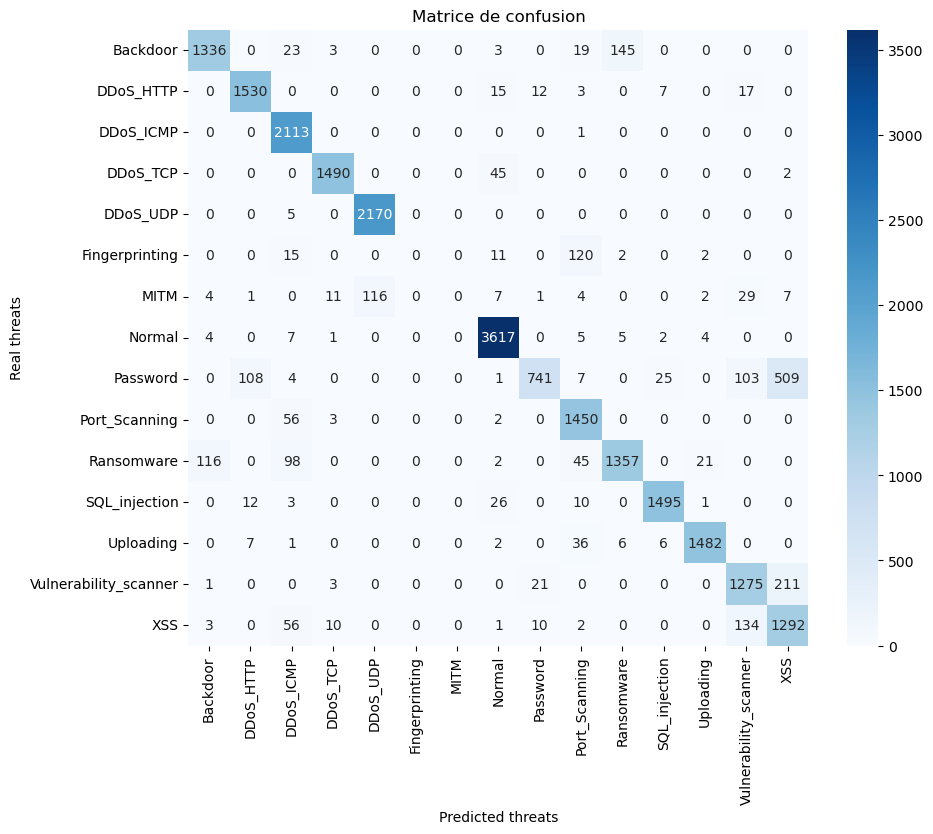

In [71]:
cm = confusion_matrix(real_values,predictions)
df_cm = pd.DataFrame(cm,index=TARGET_LIST,columns=TARGET_LIST)
show_confusion_matrix(df_cm)

In [72]:
y_true = real_values.cpu().numpy()
y_score = predictions.cpu().numpy()


In [73]:
import sklearn.metrics as metrics